In [1]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#Load dataset
df = pd.read_excel("Dataset for Data Analytics.xlsx")
print("Dataset loaded Successfully")

Dataset loaded Successfully


In [4]:
#Basic information about dataset
df.head() #display first 5 rows
df.tail() #display last 5 rows 
df.sample(5)


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
610,ORD200610,2024-06-16,C60361,Desk,5,389.62,623 Main St,Cash,Returned,TRK83566924,7,FREESHIP,Facebook,1948.10
802,ORD200802,2024-02-17,C84331,Chair,5,644.64,205 Main St,Gift Card,Cancelled,TRK34440714,6,FREESHIP,Email,3223.20
669,ORD200669,2023-02-05,C60547,Desk,1,257.00,812 Main St,Debit Card,Cancelled,TRK65694249,5,NaN,Referral,257.00
637,ORD200637,2024-09-29,C92294,Chair,4,306.35,784 Main St,Gift Card,Shipped,TRK23585765,7,WINTER15,Referral,1225.40
1003,ORD201003,2023-01-11,C84700,Printer,5,319.97,582 Main St,Cash,Shipped,TRK14706969,7,SAVE10,Google,1599.85


In [5]:
# Dataset Shape
print("Dataset Shape:")
print(df.shape)


Dataset Shape:
(1200, 14)


In [6]:
# Column Names
print("Columns:")
print(df.columns.tolist())

Columns:
['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice', 'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber', 'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice']


In [7]:
# Data Types
print("Data Types:")
print(df.dtypes)

Data Types:
OrderID                    object
Date               datetime64[ns]
CustomerID                 object
Product                    object
Quantity                    int64
UnitPrice                 float64
ShippingAddress            object
PaymentMethod              object
OrderStatus                object
TrackingNumber             object
ItemsInCart                 int64
CouponCode                 object
ReferralSource             object
TotalPrice                float64
dtype: object


In [8]:
# Dataset Information
df.info()
# Statistical Summary (Numerical Columns)
df.describe()
# Statistical Summary (Categorical Columns)
df.describe(include='object')
# Missing Values Overview
df.isnull().sum()
# Missing Values Percentage
(df.isnull().sum() / len(df)) * 100
# Check Duplicate Records
df.duplicated().sum()
# Unique Values in Each Column
df.nunique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(

OrderID            1200
Date                671
CustomerID         1189
Product               7
Quantity              5
UnitPrice          1193
ShippingAddress     655
PaymentMethod         5
OrderStatus           5
TrackingNumber     1200
ItemsInCart          10
CouponCode            3
ReferralSource        5
TotalPrice         1195
dtype: int64

In [9]:
#Missing Value Analysis
df.isnull().sum()
(df.isnull().sum()/len(df))*100

OrderID             0.00
Date                0.00
CustomerID          0.00
Product             0.00
Quantity            0.00
UnitPrice           0.00
ShippingAddress     0.00
PaymentMethod       0.00
OrderStatus         0.00
TrackingNumber      0.00
ItemsInCart         0.00
CouponCode         25.75
ReferralSource      0.00
TotalPrice          0.00
dtype: float64

In [10]:
#Handling isiing Values
df['CouponCode'] = df['CouponCode'].fillna('No Coupon')

In [11]:
df.isnull().sum()

OrderID            0
Date               0
CustomerID         0
Product            0
Quantity           0
UnitPrice          0
ShippingAddress    0
PaymentMethod      0
OrderStatus        0
TrackingNumber     0
ItemsInCart        0
CouponCode         0
ReferralSource     0
TotalPrice         0
dtype: int64

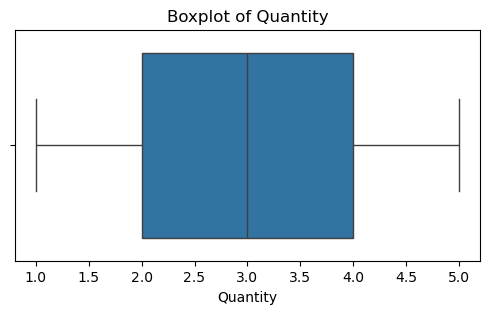

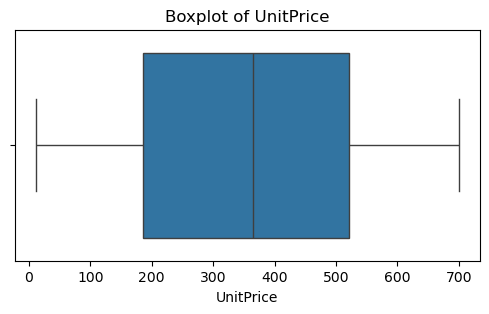

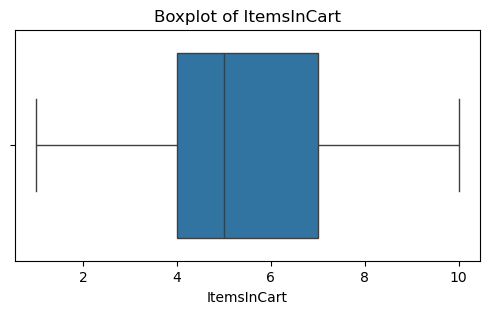

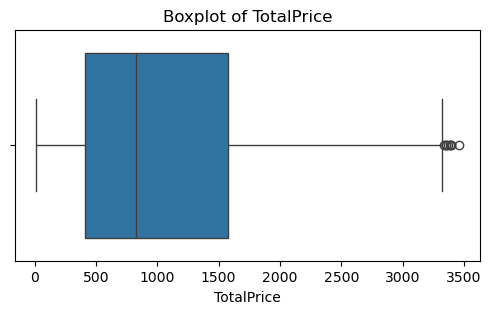

In [12]:
#Outliers Detection
numerical_cols = ['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']

for col in numerical_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [13]:
#Identifying outliers using IQR method
for col in numerical_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    print(f"{col}: {len(outliers)} outliers")

Quantity: 0 outliers
UnitPrice: 0 outliers
ItemsInCart: 0 outliers
TotalPrice: 8 outliers


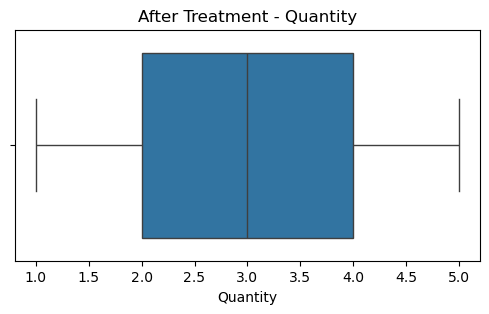

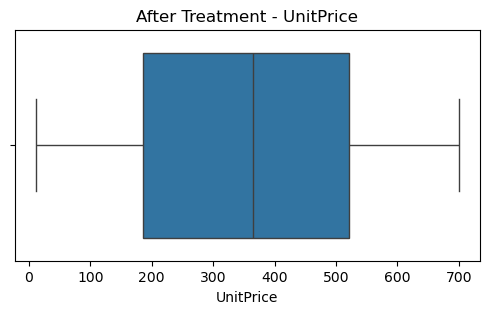

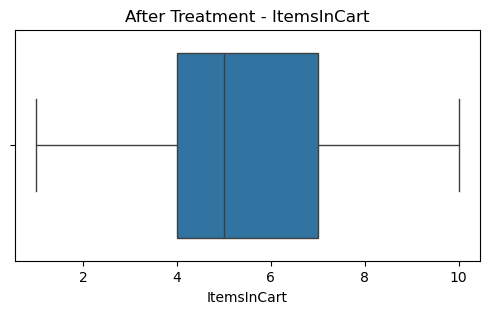

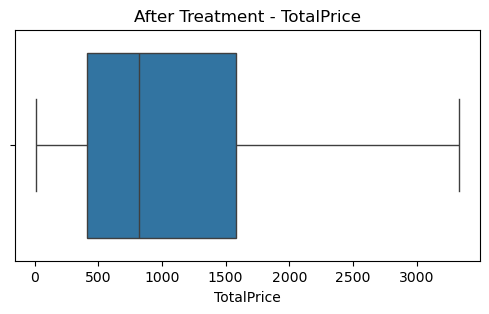

In [15]:
#Outliers Treatment
Q1 = df['TotalPrice'].quantile(0.25)
Q3 = df['TotalPrice'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df['TotalPrice'] = np.where(
    df['TotalPrice'] > upper_bound,
    upper_bound,
    np.where(
        df['TotalPrice'] < lower_bound,
        lower_bound,
        df['TotalPrice']
    )
)
for col in numerical_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f'After Treatment - {col}')
    plt.show()

In [16]:
#Feature Engineering(Fetaure 1 Order Month)
df['OrderMonth'] = df['Date'].dt.month
df[['Date', 'OrderMonth']].head()

,Date,OrderMonth
0,2023-01-04,1
1,2024-08-23,8
2,2024-02-27,2
3,2023-10-15,10
4,2025-05-08,5


In [17]:
#(Fetaure 2 Order Day)
df['OrderDay'] = df['Date'].dt.day
df[['Date', 'OrderDay']].head()

,Date,OrderDay
0,2023-01-04,4
1,2024-08-23,23
2,2024-02-27,27
3,2023-10-15,15
4,2025-05-08,8


In [18]:
#Feature 3 Coupon Used
df['CouponUsed'] = np.where(
    df['CouponCode'] == 'No Coupon',
    0,
    1
)
df[['CouponCode', 'CouponUsed']].head()

,CouponCode,CouponUsed
0,SAVE10,1
1,SAVE10,1
2,FREESHIP,1
3,SAVE10,1
4,SAVE10,1


In [19]:
#Feature 4 Average Item Cost
df['AvgItemCost'] = df['TotalPrice'] / df['Quantity']
df[['TotalPrice', 'Quantity', 'AvgItemCost']].head()

,TotalPrice,Quantity,AvgItemCost
0,2853.10,5,570.62
1,302.70,2,151.35
2,2753.40,5,550.68
3,273.19,1,273.19
4,2504.04,4,626.01


In [23]:
df.to_excel("Cleaned_Dataset_for_Data_Analytics.xlsx", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [21]:
#Verifying New features
df.columns

Index(['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
       'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice',
       'OrderMonth', 'OrderDay', 'CouponUsed', 'AvgItemCost'],
      dtype='object')